# Lab 02 · Notebook 01 — Your First Neural Network in PyTorch

In this notebook we train a small **feed-forward neural network** to recognise three species of
iris flowers from four simple measurements. The dataset is tiny, so everything runs in seconds on a
CPU — which makes it the perfect place to see *the whole machine-learning pipeline* end to end
without waiting for a GPU.

## The 6-step recipe

Almost every deep-learning project follows the same six steps. Learn this order now and you will
recognise it in every notebook for the rest of the course:

| # | Step | What we do | Key tools |
|---|------|-----------|-----------|
| 1 | **Load & preprocess data** | Read the raw numbers, look at them, put them on a comparable scale, convert to tensors | `sklearn.datasets`, `pandas`, `StandardScaler`, `torch.tensor` |
| 2 | **Split the data** | Carve out *train* / *validation* / *test* sets so we can measure honest performance | `train_test_split` |
| 3 | **Define the model** | Describe the network architecture: layers + activations | `nn.Module`, `nn.Linear`, `F.relu` |
| 4 | **Choose loss & optimizer** | Define *how wrong* the model is, and *how* to improve it | `nn.CrossEntropyLoss`, `optim.Adam` |
| 5 | **Train** | Repeatedly: predict → measure error → compute gradients → update weights | the training loop |
| 6 | **Evaluate & visualise** | Score the model on data it has never seen, and plot what happened | accuracy, loss curves, confusion matrix |

## The problem in one picture

```
     4 input features                 hidden layers                 3 output scores
  ┌────────────────────┐                                        ┌────────────────────┐
  │ sepal length (cm)  │──┐                                     │ score for setosa   │
  │ sepal width  (cm)  │──┼──▶ [10 neurons] ──▶ [10 neurons] ──▶│ score for versicol.│
  │ petal length (cm)  │──┼──▶    + ReLU          + ReLU        │ score for virginica│
  │ petal width  (cm)  │──┘                                     └────────────────────┘
  └────────────────────┘                                          the largest score
                                                                  is the prediction
```

This is a **multi-class classification** problem: exactly one of three labels is correct for each
flower.

## What you should be able to do after this notebook

* Explain why we standardise features before training a neural network.
* Explain why we need three separate data splits, not two.
* Write a PyTorch `nn.Module` from scratch and say what `forward()` does.
* Recite the four lines at the heart of every PyTorch training loop
  (`zero_grad` → `loss.backward()` → `optimizer.step()`).
* Read a loss curve and decide whether the model is *underfitting* or *overfitting*.

> **How to work through this notebook:** run the cells **in order** from top to bottom (each cell
> uses variables created by the previous ones). Read the markdown *before* you run the code cell
> below it, and compare the printed output to what the text says you should expect.

---
# Step 1 · Load and Preprocess Data

**Goal:** turn a raw dataset into two PyTorch tensors that the network can consume.

Neural networks do not understand CSV files, flower names, or Python lists — they only do
arithmetic on **tensors** (multi-dimensional arrays of numbers). So before any learning can happen
we must:

1. **Load** the dataset into memory.
2. **Look at it** (never train on data you have not inspected!).
3. **Standardise** the features so every column has a similar range of values.
4. **Convert** the result to `torch.Tensor` objects with the correct data types.

### About the IRIS dataset

A classic dataset published by the statistician Ronald Fisher in 1936. It contains **150 flowers**,
50 from each of three species, and for every flower **4 measurements** in centimetres:

| Feature | Meaning |
|---|---|
| `sepal length (cm)` | length of the outer green leaf |
| `sepal width (cm)`  | width of the outer green leaf |
| `petal length (cm)` | length of the coloured petal |
| `petal width (cm)`  | width of the coloured petal |

The **label** (`target`) is an integer code for the species: `0 = setosa`, `1 = versicolor`,
`2 = virginica`. *Setosa* is easy to separate; *versicolor* and *virginica* overlap, so that is
where our model will make most of its mistakes.

### 1.1 Load the raw dataset

`load_iris()` ships with scikit-learn, so there is nothing to download. It returns a **`Bunch`**
object — a dictionary that also allows attribute access (`iris.data` is the same as
`iris['data']`).

Printing the keys first is a good habit with *any* new dataset: it tells you what is available
before you write code that assumes a structure.

The keys you will see mean:

* **`data`** — the feature matrix, shape `(150, 4)`: 150 flowers × 4 measurements.
* **`target`** — the labels, shape `(150,)`: one integer (0/1/2) per flower.
* **`target_names`** — the human-readable species names, in label order.
* **`feature_names`** — the names of the 4 columns.
* **`DESCR`** — a long text description (try `print(iris.DESCR)` yourself!).

In [1]:
# `load_iris` is a helper that returns the built-in IRIS dataset (no download needed).
from sklearn.datasets import load_iris

# Load the dataset into a scikit-learn "Bunch": a dict-like container where you can
# access values either as iris["data"] or as iris.data
iris = load_iris()

# Always inspect the structure of a new dataset before using it.
# This tells us which fields (features, labels, names, description) are available.
print("Keys of the IRIS dataset:", iris.keys())

Keys of the IRIS dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


### 1.2 Explore the data with pandas

The raw `iris.data` is a NumPy array — fast, but hard to read. Wrapping it in a **pandas
DataFrame** gives us column names and convenient exploration tools.

Two things to check in the output below:

* **`.head()`** shows the first 5 rows, so we can confirm the columns and labels landed where we
  expect. (All 5 have `target = 0`, because the rows are sorted by species — remember this when we
  split the data later!)
* **`.describe()`** gives per-column statistics. Look carefully at the **`mean`** and **`std`**
  rows:

  | column | mean | std |
  |---|---|---|
  | sepal length | ≈ 5.84 | ≈ 0.83 |
  | sepal width  | ≈ 3.06 | ≈ 0.44 |
  | petal length | ≈ 3.76 | ≈ 1.77 |
  | petal width  | ≈ 1.20 | ≈ 0.76 |

  The columns live on **different scales** — `petal length` varies about 4× more than
  `sepal width`. That is exactly the problem the next cell fixes.

> **Note:** we also copy `target` into the DataFrame so features and labels stay aligned row by
> row. `describe()` therefore also reports statistics for `target`, but those numbers are
> meaningless (the "mean species" is not a thing) — just ignore that last column.

In [2]:
import pandas as pd

# Put the 4 feature columns into a DataFrame and give them their real names.
# iris.data  -> the 150 x 4 matrix of measurements
# iris.feature_names -> ["sepal length (cm)", "sepal width (cm)", ...]
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the labels as an extra column so each row keeps its features and its label together.
df['target'] = iris.target

# Sanity check #1: do the first rows look like valid flower measurements?
print("First 5 rows of the IRIS DataFrame:")
print(df.head())

# Sanity check #2: what is the range / spread of each column?
# Pay attention to the "mean" and "std" rows - the columns are on DIFFERENT scales,
# which is why we standardise them in the next step.
print("\nDescriptive statistics of the IRIS DataFrame:")
print(df.describe())

First 5 rows of the IRIS DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Descriptive statistics of the IRIS DataFrame:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000   

### 1.3 Standardise the features (feature scaling)

**Why bother?** A neural network learns by taking gradient steps on its weights. If one input
column has much larger values than another, that column produces much larger gradients, so the
optimizer is effectively forced to use a *different* learning rate per column. In practice
unscaled inputs mean **slower training** and often a **worse final model**.

`StandardScaler` applies the **z-score** transform to every column independently:

$$ x_{\text{scaled}} = \frac{x - \mu}{\sigma} $$

where $\mu$ is that column's mean and $\sigma$ its standard deviation. Afterwards every feature
has **mean ≈ 0** and **standard deviation ≈ 1**, so all four measurements speak "the same
language".

Two scikit-learn methods worth distinguishing:

* `fit(X)` — *learns* $\mu$ and $\sigma$ from the data and stores them inside the scaler.
* `transform(X)` — *applies* the stored $\mu$ and $\sigma$.
* `fit_transform(X)` — does both in one call (what we use here).

**What to look for in the output:** in `describe()` the means are now ~`1e-15`
(i.e. zero, up to floating-point rounding error) and the standard deviations are ~`1.0`. The
*shape* of the data has not changed at all — only its units. A flower that was large relative to
the others is still large; it now simply reads as `+1.3 standard deviations` instead of `6.9 cm`.

> ⚠️ **Important caveat for later:** we are fitting the scaler on **all 150 rows**, *before*
> splitting off a test set. That leaks a little information about the test rows (their mean and
> std) into our preprocessing — a mild form of **data leakage**. It is harmless for a teaching
> example, but in a real project the correct order is: **split first**, then
> `scaler.fit_transform(X_train)` and `scaler.transform(X_val)` / `scaler.transform(X_test)`.
> Try rewriting the notebook that way as an exercise.

In [3]:
from sklearn.preprocessing import StandardScaler

# Separate the inputs from the labels.
# X = what the network sees (4 measurements);  y = what it must predict (species 0/1/2).
X = df.drop('target', axis=1)   # axis=1 -> drop a COLUMN (axis=0 would drop a row)
y = df['target']

# Create the scaler. Nothing is computed yet - it is an empty "recipe" object.
scaler = StandardScaler()

# fit_transform() does two things at once:
#   fit       -> compute the mean and std of EACH of the 4 columns
#   transform -> replace every value x by  (x - mean) / std
# Result: every feature now has mean ~0 and std ~1. Returns a NumPy array.
X_scaled = scaler.fit_transform(X)

# Rebuild a DataFrame so the printout below is readable, and re-attach the labels.
# NOTE: labels are NEVER scaled - they are class IDs, not measurements.
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['target'] = y

# The values now look "small" and are centred around zero, including negative numbers.
print("First 5 rows of the scaled IRIS DataFrame:")
print(df_scaled.head())

# Confirm the transformation worked: mean ~ 0 (printed as ~1e-15) and std ~ 1 for all 4 features.
print("\nDescriptive statistics of the scaled IRIS DataFrame:")
print(df_scaled.describe())

First 5 rows of the scaled IRIS DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   
3          -1.506521          0.098217          -1.283389         -1.315444   
4          -1.021849          1.249201          -1.340227         -1.315444   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Descriptive statistics of the scaled IRIS DataFrame:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count       1.500000e+02      1.500000e+02       1.500000e+02   
mean       -1.468455e-15     -1.823726e-15      -1.610564e-15   
std         1.003350e+00      1.003350e+00       1.003350e+00   
min        -1.870024e+00     -2.433947e+00      -1.567576e+00   
25%        -9.006812e-01     -5

### 1.4 Convert to PyTorch tensors

A `torch.Tensor` is PyTorch's array type. Compared to a NumPy array it adds two superpowers we
need: it can live on a **GPU**, and it can **track gradients** for automatic differentiation.

The **data types are not interchangeable** here, and getting them wrong is one of the most common
beginner errors:

| Tensor | `dtype` | Why |
|---|---|---|
| `X_tensor` (features) | `torch.float32` | Network weights are `float32`; a matrix multiply between `float64` inputs and `float32` weights raises a `RuntimeError`. `float32` is also the standard precision for deep learning — fast and accurate enough. |
| `y_tensor` (labels) | `torch.long` (= `int64`) | `nn.CrossEntropyLoss` expects **class indices** as 64-bit integers, *not* floats and *not* one-hot vectors. Passing floats here gives an error. |

**Expected shapes:**

* `X_tensor` → `torch.Size([150, 4])` — read this as *150 samples, 4 features each*. The first
  dimension is always the **batch dimension** in PyTorch.
* `y_tensor` → `torch.Size([150])` — one label per sample, a flat 1-D vector.

> **Habit to build:** print `.shape` after every reshaping step. Most PyTorch bugs are shape bugs,
> and they are far easier to catch here than inside a training loop.

In [4]:
import torch

# torch.tensor(...) copies the values from a NumPy array into a PyTorch tensor.
# `.values` pulls the raw NumPy array out of the pandas DataFrame/Series.

# Features -> float32, because neural network weights are float32.
X_tensor = torch.tensor(df_scaled.drop('target', axis=1).values, dtype=torch.float32)

# Labels -> torch.long (int64), because CrossEntropyLoss expects integer class indices.
y_tensor = torch.tensor(df_scaled['target'].values, dtype=torch.long)

# Verify BOTH the shape and the dtype - these two lines catch most PyTorch beginner bugs.
print("Shape of X_tensor:", X_tensor.shape)      # expect [150, 4]  = 150 samples, 4 features
print("Data type of X_tensor:", X_tensor.dtype)  # expect torch.float32
print("Shape of y_tensor:", y_tensor.shape)      # expect [150]     = one label per sample
print("Data type of y_tensor:", y_tensor.dtype)  # expect torch.int64 (this is what "long" means)

Shape of X_tensor: torch.Size([150, 4])
Data type of X_tensor: torch.float32
Shape of y_tensor: torch.Size([150])
Data type of y_tensor: torch.int64


---
# Step 2 · Split the Data

**Goal:** create three disjoint subsets so we can measure how well the model generalises to
flowers it has never seen.

### Why three sets and not two?

| Split | Size here | Who "sees" it | Used for |
|---|---|---|---|
| **Training set** | 120 flowers (80%) | the optimizer | updating the weights — this is what the model learns from |
| **Validation set** | 15 flowers (10%) | you, the developer | monitoring during training and choosing **hyper-parameters** (learning rate, number of layers, when to stop) |
| **Test set** | 15 flowers (10%) | nobody, until the very end | one final, honest estimate of real-world performance |

If we tuned our settings against the test set, we would be *indirectly* fitting to it, and our
reported accuracy would be optimistically biased. Keeping a third, untouched set is what makes the
final number trustworthy. **Rule: look at the test set once, at the end.**

### The two-call trick

`train_test_split` only splits into *two* parts, so we call it twice:

```
150 samples
   └── split #1 (test_size=0.2) ──▶ 120 train  +  30 "temp"
                                              └── split #2 (test_size=0.5) ──▶ 15 val + 15 test
```

### Two arguments that matter a lot

* **`stratify=y`** — preserves the class proportions in every split. Remember that the IRIS rows
  are *sorted by species*: without stratification an unlucky random split could put almost no
  *virginica* in the training set. With `stratify`, each split keeps the 1/3–1/3–1/3 balance.
* **`random_state=42`** — fixes the random seed, so you and your classmates get **exactly the same
  split** and therefore comparable results. The number itself is arbitrary; *reproducibility* is
  the point.

> **Reality check:** 15 samples is a *very* small validation/test set — a single flower is worth
> 6.7% accuracy, so the scores will jump around. That is a genuine limitation of this toy setup,
> and a good motivation for **k-fold cross-validation**, which you will meet later.

### 2.1 Perform the two splits

`train_test_split` accepts the features and the labels together and shuffles them **in the same
order**, so row *i* of `X_train` always keeps its own label in `y_train` — this is why you must
never shuffle features and labels separately by hand.

It happily accepts PyTorch tensors and returns PyTorch tensors, so no conversion is needed here.

**What to check in the output:** `120 + 15 + 15 = 150`. If the numbers do not add up, re-read the
`test_size` values above. Also convince yourself *why* `test_size=0.5` in the second call gives 15
and not 75: it is 50% **of the 30 temporary samples**, not of the original 150.

In [5]:
from sklearn.model_selection import train_test_split

# --- Split #1: pull out 20% of the data as a temporary hold-out ------------------------
# test_size=0.2      -> 20% of 150 = 30 samples go to X_temp, the other 120 to X_train
# random_state=42    -> fixed seed, so this split is identical every time you run the cell
# stratify=y_tensor  -> keep the same class balance (1/3 per species) in both parts
X_train, X_temp, y_train, y_temp = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

# --- Split #2: cut the 30 hold-out samples in half -> validation and test -------------
# test_size=0.5 of the 30 temp samples -> 15 validation + 15 test
# stratify=y_temp -> again keep the classes balanced in both halves
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Check the sizes add up: 120 + 15 + 15 = 150. If they do not, something went wrong above.
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")  # 120 samples
print(f"X_val   shape: {X_val.shape}, y_val   shape: {y_val.shape}")      #  15 samples
print(f"X_test  shape: {X_test.shape}, y_test  shape: {y_test.shape}")    #  15 samples

X_train shape: torch.Size([120, 4]), y_train shape: torch.Size([120])
X_val shape: torch.Size([15, 4]), y_val shape: torch.Size([15])
X_test shape: torch.Size([15, 4]), y_test shape: torch.Size([15])


---
# Step 3 · Define the Neural Network

**Goal:** describe the architecture — how many layers, how wide, and which activation functions.

In PyTorch every model is a Python class that inherits from **`nn.Module`** and implements two
methods:

* **`__init__`** — *create* the layers (this is where the learnable parameters are born).
* **`forward`** — *use* the layers: describe how an input flows through the network to an output.

You never call `forward()` yourself. You call `model(x)`, and PyTorch calls `forward` for you
(plus some bookkeeping needed for gradients).

### Our architecture

| Layer | Definition | Shape transformation | Learnable parameters |
|---|---|---|---|
| `fc1` | `nn.Linear(4, 10)` | `[batch, 4]` → `[batch, 10]` | 4×10 weights + 10 biases = **50** |
| ReLU  | `F.relu` | shape unchanged | 0 (it is just a function) |
| `fc2` | `nn.Linear(10, 10)` | `[batch, 10]` → `[batch, 10]` | 10×10 + 10 = **110** |
| ReLU  | `F.relu` | shape unchanged | 0 |
| `fc3` | `nn.Linear(10, 3)` | `[batch, 10]` → `[batch, 3]` | 10×3 + 3 = **33** |

Total: **193 learnable parameters** — a tiny network by modern standards (real models have
billions), but plenty for 4 features and 3 classes.

`fc` stands for *fully connected*: every neuron in the layer receives every value from the
previous layer. Each `nn.Linear` computes $y = xW^\top + b$, and its weights are initialised
randomly when it is created.

### Two questions students always ask

**1. Why do we need ReLU at all?**
`ReLU(x) = max(0, x)`. Without a non-linear function between the layers, stacking three linear
layers would collapse mathematically into a *single* linear layer — the network could only draw
straight decision boundaries, no matter how many layers you add. ReLU is what lets the network
learn curved, non-linear boundaries. It is the default choice because it is cheap to compute and
does not saturate for positive inputs.

**2. Why is there no softmax on the output layer?**
Because `nn.CrossEntropyLoss` **applies log-softmax internally**. The 3 raw numbers coming out of
`fc3` are called **logits**: unbounded scores where "bigger means more likely". Adding your own
`softmax` before the loss would apply it twice, flatten the gradients, and slow learning down.

* During **training** → feed the raw logits to the loss.
* At **prediction** time → the class with the largest logit is the answer (`torch.max(..., 1)`),
  which is the same as the largest softmax probability.
* Only if you need actual **probabilities** to show a user, apply `torch.softmax(logits, dim=1)`
  explicitly.

### 3.1 Write the model class

Read the code below in this order:

1. `super().__init__()` — **mandatory** first line. It runs `nn.Module`'s constructor, which sets
   up the internal machinery that tracks parameters. Forget it and PyTorch cannot find your
   weights.
2. The three `nn.Linear` layers, assigned to `self.` — assigning to `self` is what **registers**
   them, so they appear in `model.parameters()` and get updated by the optimizer.
3. `forward(self, x)` — the data path. Note that the numbers must **chain**: `fc1` outputs 10,
   so `fc2` must accept 10. A mismatch here is the classic "shape error" crash.

Defining a class does not create a network yet — it only describes one, which is why the cell just
prints a confirmation message.

In [6]:
import torch.nn as nn               # layer building blocks (Linear, Conv2d, ...)
import torch.nn.functional as F     # stateless functions (relu, softmax, ...)


class IrisNet(nn.Module):
    '''A small fully-connected classifier: 4 features -> 10 -> 10 -> 3 class scores.'''

    def __init__(self):
        # ALWAYS call the parent constructor first: it initialises the nn.Module
        # machinery that keeps track of layers and their learnable parameters.
        super(IrisNet, self).__init__()

        # Define the layers. Assigning them to `self.` registers their weights with the
        # module, so model.parameters() (and therefore the optimizer) can find them.
        # The numbers must chain: out_features of one layer = in_features of the next.
        self.fc1 = nn.Linear(4, 10)   # input layer:  4 features        -> 10 neurons
        self.fc2 = nn.Linear(10, 10)  # hidden layer: 10 neurons        -> 10 neurons
        self.fc3 = nn.Linear(10, 3)   # output layer: 10 neurons        -> 3 class scores

    def forward(self, x):
        '''Describes how an input batch x of shape [batch_size, 4] flows to the output.'''
        # Layer 1 + ReLU non-linearity.  ReLU(x) = max(0, x)
        # Without a non-linearity, three stacked Linear layers would collapse into one.
        x = F.relu(self.fc1(x))       # [batch, 4]  -> [batch, 10]

        # Layer 2 + ReLU
        x = F.relu(self.fc2(x))       # [batch, 10] -> [batch, 10]

        # Output layer: NO activation here on purpose.
        # These 3 raw numbers are "logits"; nn.CrossEntropyLoss applies softmax itself.
        x = self.fc3(x)               # [batch, 10] -> [batch, 3]
        return x


# Note: this only DEFINES the blueprint. No weights exist until we instantiate it below.
print("IrisNet class defined successfully.")

IrisNet class defined successfully.


### 3.2 Create (instantiate) the model

Calling `IrisNet()` runs `__init__`, which allocates the three layers and fills their weights with
**random** values (PyTorch uses a sensible default initialisation, so we do not have to think
about it here). At this moment the model can already make predictions — they will just be garbage,
about 33% accurate, i.e. random guessing among three classes.

Two commands worth trying yourself in a new cell:

```python
print(model)                                                     # a summary of the layers
print(sum(p.numel() for p in model.parameters()))                # -> 193 parameters
print(model(X_train[:1]))                                        # 3 logits for one flower
```

> **Watch out:** re-running this cell creates a *brand new* model with fresh random weights and
> throws away all training done so far. If your accuracy suddenly drops back to ~33%, check
> whether you re-ran this cell. Also note that the optimizer in Step 4 is bound to *this* model
> object — so if you re-create the model, re-run the optimizer cell too.

In [7]:
# Instantiate the network: this runs __init__ and creates all 193 weights and biases,
# initialised with small random values. The model is usable immediately, but untrained
# (expect ~33% accuracy = random guessing between 3 classes).
model = IrisNet()

print("IrisNet model instantiated successfully.")

# Uncomment these to inspect what you just built:
# print(model)                                                # layer-by-layer summary
# print("Trainable parameters:", sum(p.numel() for p in model.parameters()))  # -> 193

IrisNet model instantiated successfully.


---
# Step 4 & 5 · Loss, Optimizer, and the Training Loop

**Goal:** teach the random weights to classify irises.

Training is a loop over the same three questions, repeated many times:

```
   ┌──────────────────────────────────────────────────────────────────┐
   │  1. FORWARD   predictions = model(X)         "what do I think?"  │
   │  2. LOSS      loss = criterion(pred, y)      "how wrong am I?"   │
   │  3. BACKWARD  loss.backward()                "which direction?"  │
   │  4. STEP      optimizer.step()               "take a step"       │
   └──────────────────────────────────────────────────────────────────┘
                              repeat for each epoch
```

Two objects drive steps 2–4:

### The loss function — `nn.CrossEntropyLoss`

The standard loss for multi-class classification. It takes the **raw logits** (shape
`[batch, 3]`) plus the **integer labels** (shape `[batch]`) and internally does
`log_softmax` followed by negative log-likelihood. It is *low* when the model puts a high score on
the correct class and *high* when it does not.

Useful reference point: a model that guesses uniformly over 3 classes has a loss of
$-\ln(1/3) \approx 1.10$. So when you see the first epochs printing ≈1.10, that means
"still guessing" — and a loss clearly below that means real learning has started.

### The optimizer — `optim.Adam`

The optimizer holds the rule for turning gradients into weight updates. We hand it
`model.parameters()` so it knows *which* tensors to modify.

* **Adam** adapts a per-parameter step size automatically, which makes it a robust default that
  usually beats plain SGD without tuning.
* **`lr=0.001`** is the *learning rate* — the single most important hyper-parameter. Too small →
  training crawls (you will see this happen below!). Too large → the loss oscillates or explodes.

### 4.1 Create the loss function and the optimizer

Note the argument to `Adam`: `model.parameters()` is a generator over every tensor we registered
in `__init__`. This is the wiring that connects *the thing being optimised* (the model) to
*the thing doing the optimising* (the optimizer). If you ever create a new model, you must create
a new optimizer as well — otherwise it keeps updating the old, discarded weights.

In [8]:
import torch.optim as optim

# The LOSS FUNCTION ("criterion") measures how wrong the predictions are.
# CrossEntropyLoss is the standard choice for multi-class classification. It expects:
#   - predictions: raw logits, shape [batch_size, num_classes]   (NO softmax applied!)
#   - targets:     integer class indices, shape [batch_size], dtype long
# Reference value: random guessing over 3 classes gives a loss of -ln(1/3) = 1.0986
criterion = nn.CrossEntropyLoss()

# The OPTIMIZER updates the weights using the gradients computed by loss.backward().
#   model.parameters() -> tells Adam WHICH tensors it is allowed to change (all 193 of them)
#   lr=0.001           -> learning rate: how big each update step is
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function (CrossEntropyLoss) and Optimizer (Adam) defined successfully.")

Loss function (CrossEntropyLoss) and Optimizer (Adam) defined successfully.


### 5.1 The training loop

This is the most important cell in the notebook. Read it slowly — the same skeleton appears in
every PyTorch project you will ever write.

#### The four lines you must memorise

```python
optimizer.zero_grad()   # 1. clear the gradients left over from the previous step
loss = criterion(model(X), y)
loss.backward()         # 2. backpropagation: compute d(loss)/d(weight) for every weight
optimizer.step()        # 3. nudge every weight a little in the direction that lowers the loss
```

Why is `zero_grad()` needed? Because PyTorch **accumulates** gradients into `.grad` by default
(handy for some advanced tricks). If you forget it, step *n* is polluted by the gradients of all
previous steps and training goes haywire. This is *the* classic PyTorch bug.

#### `model.train()` vs `model.eval()`

These switch the module's **mode flag**. Layers such as `Dropout` and `BatchNorm` behave
differently while training and while predicting, and this flag is how they know which to use. Our
tiny network contains neither layer, so the calls change nothing *here* — but writing them now
builds the habit that will save you from silent bugs in bigger models.

#### `with torch.no_grad()`

Inside this block PyTorch stops building the computation graph. We use it for validation because
we are only *measuring*, never learning, from that data. Benefits: less memory, faster, and it
makes it impossible to accidentally train on the validation set.

#### How accuracy is computed

```python
_, predicted = torch.max(outputs.data, 1)   # take the argmax over dimension 1 (the classes)
correct = (predicted == y).sum().item()     # count the matches -> Python number via .item()
```

`torch.max` returns *two* values, `(max_values, max_indices)`. We only need the **indices**
(= the predicted class), so the values are thrown away into `_`, the conventional
"I do not need this" variable name.

#### ⚠️ One thing that is unusual about this loop

We pass the **entire** training set (all 120 samples) through the network in one go, so each epoch
performs exactly **one** weight update — 100 epochs means only **100 updates**. This is called
**full-batch gradient descent**, and it is only practical because our dataset is tiny.

That is also why the result below is disappointing: after 100 tiny steps the loss is still ~0.87
(remember, random guessing ≈1.10) and the model is clearly **underfitting** — it simply has not
finished learning yet. Do not treat this as the final word on the model; the exercises at the end
of the notebook show the three ways to fix it. Real projects instead loop over **mini-batches**
with a `DataLoader`, getting many updates per epoch.

In [9]:
epochs = 100          # how many times we pass over the whole training set

# Lists to record the learning history, so we can plot the curves afterwards.
# We track loss AND accuracy, for BOTH training and validation data.
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):

    # ======================= TRAINING PHASE ==========================================
    model.train()          # switch to training mode (matters for Dropout/BatchNorm layers)

    # STEP 1: clear old gradients. PyTorch ACCUMULATES gradients by default, so without
    # this the update below would mix in gradients from previous epochs. Classic bug!
    optimizer.zero_grad()

    # STEP 2: forward pass - feed ALL 120 training samples through the network at once.
    # outputs has shape [120, 3]: three raw logits per flower.
    outputs = model(X_train)

    # STEP 3: how wrong are we? Compare logits with the true class indices.
    loss = criterion(outputs, y_train)

    # STEP 4: backward pass (backpropagation). Fills p.grad for every parameter p
    # with the derivative of the loss with respect to that parameter.
    loss.backward()

    # STEP 5: let the optimizer nudge every weight in the direction that reduces the loss.
    # NOTE: with the full batch above, this is only ONE weight update per epoch.
    optimizer.step()

    # ----- training accuracy for this epoch -----
    # torch.max(..., 1) returns (max_values, max_indices) along dimension 1 (the classes).
    # We only want the index of the largest logit = the predicted class, so values go to `_`.
    _, predicted = torch.max(outputs.data, 1)
    total_train = y_train.size(0)                            # 120
    correct_train = (predicted == y_train).sum().item()       # count correct predictions
    train_accuracy = correct_train / total_train

    train_losses.append(loss.item())        # .item() converts a 1-element tensor to a float
    train_accuracies.append(train_accuracy)

    # ======================= VALIDATION PHASE ========================================
    model.eval()               # switch to evaluation mode
    with torch.no_grad():      # no gradients here: we are measuring, not learning
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

        # Same accuracy computation as above, now on the 15 validation samples.
        _, val_predicted = torch.max(val_outputs.data, 1)
        total_val = y_val.size(0)                            # 15
        correct_val = (val_predicted == y_val).sum().item()
        val_accuracy = correct_val / total_val

        val_losses.append(val_loss.item())
        val_accuracies.append(val_accuracy)

    # Print a progress report every 10 epochs (printing every epoch would be too noisy).
    # Watch the loss start near 1.10 (= random guessing) and slowly decrease.
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], '
              f'Train Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy:.4f}, '
              f'Val Loss: {val_loss.item():.4f}, Val Accuracy: {val_accuracy:.4f}')

print("Model training complete.")

Epoch [10/100], Train Loss: 1.0983, Train Accuracy: 0.3333, Val Loss: 1.0940, Val Accuracy: 0.3333
Epoch [20/100], Train Loss: 1.0838, Train Accuracy: 0.3333, Val Loss: 1.0798, Val Accuracy: 0.3333
Epoch [30/100], Train Loss: 1.0687, Train Accuracy: 0.3333, Val Loss: 1.0645, Val Accuracy: 0.3333
Epoch [40/100], Train Loss: 1.0527, Train Accuracy: 0.5750, Val Loss: 1.0482, Val Accuracy: 0.6667
Epoch [50/100], Train Loss: 1.0342, Train Accuracy: 0.6583, Val Loss: 1.0301, Val Accuracy: 0.6667
Epoch [60/100], Train Loss: 1.0126, Train Accuracy: 0.6667, Val Loss: 1.0089, Val Accuracy: 0.8000
Epoch [70/100], Train Loss: 0.9871, Train Accuracy: 0.7167, Val Loss: 0.9837, Val Accuracy: 0.9333
Epoch [80/100], Train Loss: 0.9557, Train Accuracy: 0.8083, Val Loss: 0.9536, Val Accuracy: 0.8667
Epoch [90/100], Train Loss: 0.9172, Train Accuracy: 0.8250, Val Loss: 0.9171, Val Accuracy: 0.8667
Epoch [100/100], Train Loss: 0.8722, Train Accuracy: 0.8417, Val Loss: 0.8715, Val Accuracy: 0.8667
Model tra

---
# Step 6 · Evaluate on the Test Set

**Goal:** get one honest number for how well this model handles data that influenced neither its
weights nor our design choices.

The code is the *validation* block from the training loop, run once on `X_test`. The three
ingredients that make it an evaluation rather than a training step:

1. **`model.eval()`** — put the network in inference mode.
2. **`with torch.no_grad()`** — do not build a computation graph, do not compute gradients.
3. **No `loss.backward()` and no `optimizer.step()`** — nothing is learned from this data.

**Accuracy** is simply *correct predictions ÷ total predictions*. It is the natural first metric
here because our three classes are perfectly balanced; on **imbalanced** data accuracy is
misleading (predicting "the majority class" always would score well) and you would reach for
precision, recall, or F1 instead.

### How to read the result you get

The test accuracy comes out around **0.60**, noticeably below the ~0.87 validation accuracy at the
end of training. Two things are going on, and both are worth understanding:

* The model is **undertrained** (see the note on full-batch gradient descent above) — 100 updates
  at `lr=0.001` are simply not enough to converge.
* The test set holds **15 samples**, so every single flower moves the score by 6.7%. With numbers
  this small, a gap between validation and test accuracy is mostly **noise**, not evidence of
  overfitting. Never over-interpret a metric computed on 15 examples.

A well-trained model on IRIS typically reaches **93–100%** test accuracy. The exercises at the end
show how to get there.

### 6.1 Run the model on the test data

In [10]:
model.eval()   # evaluation mode: no Dropout, BatchNorm uses running statistics

# torch.no_grad() disables gradient tracking -> faster, uses less memory, and makes it
# impossible to accidentally train on the test set.
with torch.no_grad():
    # Forward pass on the 15 unseen test flowers -> logits of shape [15, 3]
    test_outputs = model(X_test)

    # Pick the class with the highest logit as the prediction (argmax over the class axis).
    _, test_predicted = torch.max(test_outputs.data, 1)

    # Accuracy = (number of correct predictions) / (number of samples)
    total_test = y_test.size(0)                          # 15
    correct_test = (test_predicted == y_test).sum().item()
    test_accuracy = correct_test / total_test

# This is the final, honest score - the only time we look at the test set.
print(f'Test Accuracy: {test_accuracy:.4f}')
# Reminder: with only 15 test samples, each mistake costs 1/15 = 6.7% accuracy.

Test Accuracy: 0.6000


---
# Step 7 · Visualise the Training History and the Results

**Goal:** a single number never tells the whole story. Two plots tell us *what happened during
training* and *which classes get confused*.

### Plot 1 & 2 — loss and accuracy curves

We plot the **training** and **validation** curves on the same axes, because the *gap and shape*
between them is the diagnostic, not either curve alone:

| What you see | Diagnosis | What to do |
|---|---|---|
| Both losses still falling steeply at the last epoch | **Underfitting** — training stopped too early | train longer, raise the learning rate, use mini-batches |
| Both losses flat and high | Model too simple, or learning rate too small | bigger network / tune the learning rate |
| Training loss ↓ while validation loss ↑ | **Overfitting** — memorising the training set | early stopping, regularisation, more data |
| Both low and flat, small gap | 🎉 Well-fitted model | stop and evaluate on the test set |

**Our curves show the first case:** both losses are still marching downwards at epoch 100, and
accuracy is still climbing. The model was interrupted mid-learning. Note also how the validation
accuracy curve moves in coarse jumps — each step is one of only 15 samples flipping from wrong to
right.

### Plot 3 — the confusion matrix

Accuracy tells you *how many* mistakes; a confusion matrix tells you *which* mistakes. Row =
true species, column = predicted species, so:

* the **diagonal** holds the correct predictions,
* everything **off the diagonal** is an error, and its position names the confusion.

For IRIS you should expect *setosa* to be classified perfectly (it is linearly separable from the
other two), with the errors concentrated between **versicolor** and **virginica**, whose
measurements genuinely overlap. Confirming that expectation in the plot is a good sign that your
model is learning something botanically real rather than random noise.

### 7.1 Plot the loss and accuracy curves

`plt.subplot(1, 2, i)` means: *in a grid of 1 row × 2 columns, make plot number `i` active.* Every
plotting command after it draws into that panel.

Notice the plotting essentials, which we expect in your own submissions too:
`xlabel`, `ylabel`, `title`, and — because each panel holds two lines — a `legend()`. An unlabelled
plot is not a result.

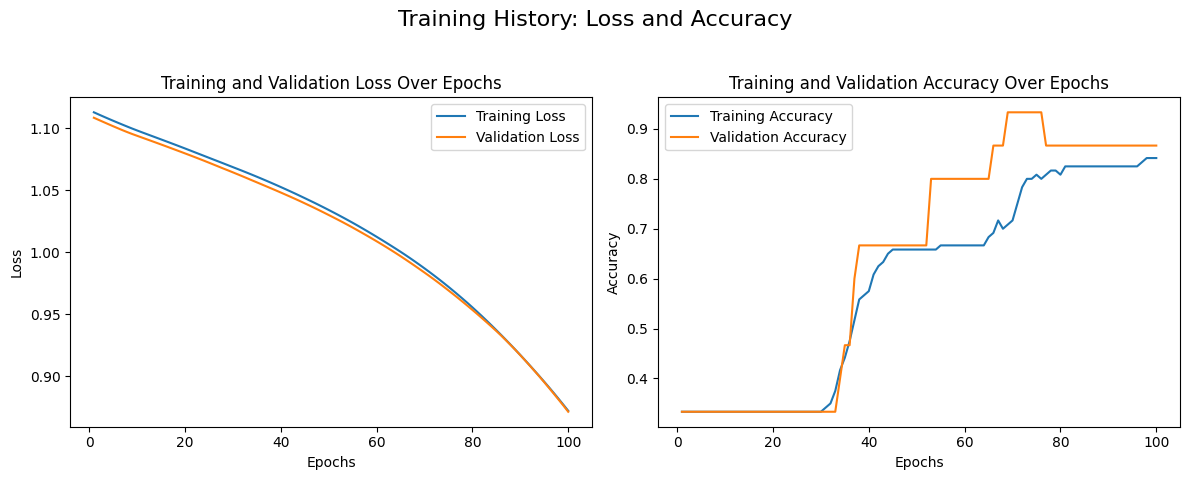

In [11]:
import matplotlib.pyplot as plt

# One wide figure that will hold two side-by-side panels.
plt.figure(figsize=(12, 5))

# --------- Panel 1: loss curves ------------------------------------------------------
plt.subplot(1, 2, 1)            # grid of 1 row x 2 columns -> activate the 1st panel
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()                    # ALWAYS add a legend when a panel has more than one line
# Read it like this: both curves still falling at epoch 100 => the model is UNDERFITTING
# (we stopped too early). Training down + validation up would mean OVERFITTING instead.

# --------- Panel 2: accuracy curves --------------------------------------------------
plt.subplot(1, 2, 2)            # activate the 2nd panel
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.legend()
# The validation curve moves in big steps because it is measured on only 15 samples,
# so one flower changing from wrong to right shifts it by 1/15 = 6.7%.

# A single title for the whole figure, then tidy the spacing so nothing overlaps.
plt.suptitle('Training History: Loss and Accuracy', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])   # leave 5% at the top for the suptitle
plt.show()

### 7.2 Plot the confusion matrix

`confusion_matrix` is a scikit-learn function, and scikit-learn speaks **NumPy**, not PyTorch — so
we first convert our tensors with `.numpy()`. (This works because the tensors are on the CPU and
detached from the graph; for a GPU tensor you would need `.cpu().numpy()`, and for one that still
tracks gradients, `.detach()`.)

`ConfusionMatrixDisplay` then draws the matrix with the real species names instead of `0/1/2`,
which makes it far easier to interpret. Passing `display_labels=iris.target_names` is what turns
the axis ticks into `setosa`, `versicolor`, `virginica`.

**How to read the grid:** pick a row (the true species) and follow it across. A count in the
diagonal cell is a correct prediction; a count anywhere else tells you exactly which species the
model mistook it for.

> **Small quirk in the code below:** `plt.figure(...)` is called *before* `disp.plot()`, but
> `ConfusionMatrixDisplay.plot()` creates its own figure — so the empty one we made is discarded
> and the `figsize` has no effect. The clean way is
> `fig, ax = plt.subplots(figsize=(8, 6))` followed by `disp.plot(ax=ax, cmap=plt.cm.Blues)`.
> Try it and watch the extra blank figure disappear.

<Figure size 800x600 with 0 Axes>

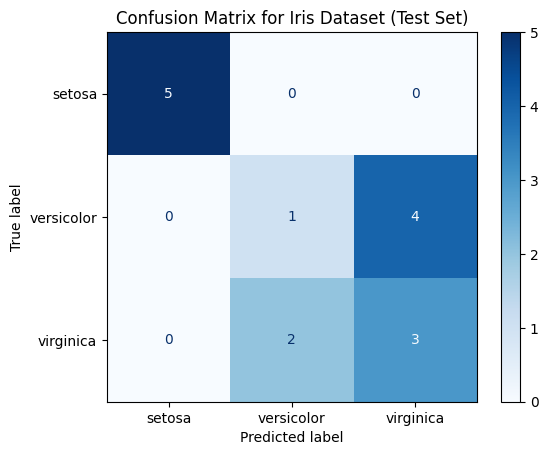

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# scikit-learn works with NumPy arrays, so convert the PyTorch tensors first.
# (These tensors are on the CPU and gradient-free; otherwise you would need
#  .detach().cpu().numpy() instead.)
y_test_np = y_test.numpy()                   # the 15 true labels
test_predicted_np = test_predicted.numpy()   # the 15 predicted labels

# Build the matrix: cm[i, j] = number of samples whose TRUE class is i and PREDICTED class is j.
# The diagonal (i == j) therefore counts correct predictions; everything else is an error.
cm = confusion_matrix(y_test_np, test_predicted_np)

# Use the real species names for the axis ticks instead of 0 / 1 / 2 - much easier to read.
class_names = iris.target_names   # ['setosa', 'versicolor', 'virginica']

# Wrap the matrix in a display helper that knows how to draw it as a heat map.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# NOTE: disp.plot() creates its OWN figure, so the plt.figure() below has no effect
# (it just leaves an empty extra figure). The clean version is:
#     fig, ax = plt.subplots(figsize=(8, 6))
#     disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)     # darker cell = more samples
plt.title('Confusion Matrix for Iris Dataset (Test Set)')
plt.show()

# Expected pattern for IRIS: 'setosa' is predicted perfectly, and the mistakes sit between
# 'versicolor' and 'virginica', whose petal/sepal measurements genuinely overlap.

---
# Step 8 · Summary, Findings, and Exercises

## What we did

| Step | Result |
|---|---|
| 1. Loaded & preprocessed | 150 flowers × 4 features, standardised to mean 0 / std 1, converted to tensors |
| 2. Split | 120 train / 15 validation / 15 test, class-balanced (`stratify`) |
| 3. Model | `IrisNet`: 4 → 10 → 10 → 3, ReLU activations, **193** learnable parameters |
| 4. Loss & optimizer | `CrossEntropyLoss` + `Adam(lr=0.001)` |
| 5. Trained | 100 epochs of **full-batch** gradient descent = 100 weight updates |
| 6. Evaluated | Train ≈ 0.84, Validation ≈ 0.87, **Test ≈ 0.60** |
| 7. Visualised | Loss/accuracy curves + confusion matrix |

## Key findings

1. **The model is underfitting, not overfitting.** Both loss curves are still falling at epoch
   100, and the training loss (≈0.87) is barely below the random-guessing baseline of 1.10. The
   network never got the chance to converge.
2. **The cause is the update budget, not the architecture.** With one full-batch update per epoch
   and `lr=0.001`, 100 epochs give only 100 small steps. 193 parameters are plenty for IRIS —
   this same network reaches ~97% once it is trained properly.
3. **The metrics are noisy by construction.** 15 validation and 15 test samples mean a resolution
   of 6.7% per flower, so the validation/test gap (0.87 vs 0.60) is largely sampling luck. Report
   such numbers with caution.
4. **The confusion matrix localises the difficulty.** *Setosa* is separable from the other two;
   *versicolor* vs *virginica* is where the real work is.

## Exercises — fix the model

Work through these in order. Re-run the model-instantiation cell **and** the optimizer cell before
each experiment, so you always start from fresh random weights.

1. **Train longer.** Set `epochs = 2000`. How high does the test accuracy get? Where do the loss
   curves flatten out?
2. **Raise the learning rate.** Keep `epochs = 100` but use `lr=0.01`, then `lr=0.1`. What does a
   *too large* learning rate look like in the loss curve?
3. **Use mini-batches.** Wrap the training tensors in a `TensorDataset` and a `DataLoader` with
   `batch_size=16, shuffle=True`, and loop over batches inside each epoch. You now get 8 updates
   per epoch instead of 1 — compare convergence at the same number of epochs.
4. **Fix the data leakage.** Split the data *before* scaling: fit `StandardScaler` on the training
   set only, then `transform` the validation and test sets. Does the score change?
5. **Bigger splits.** Use a 60/20/20 split so validation and test have 30 samples each. Are the
   curves smoother?
6. **Ablate the non-linearity.** Delete both `F.relu` calls, leaving three stacked linear layers.
   Explain the accuracy you get in terms of what the network can now represent.
7. **See the probabilities.** Apply `torch.softmax(test_outputs, dim=1)` and print them next to
   the true labels. Which flowers is the model least confident about, and do they match the
   off-diagonal cells of the confusion matrix?

## Where this goes next

The pattern you just followed — *data → split → model → loss/optimizer → loop → evaluate* —
does not change when the data becomes images and the model becomes a 50-layer convolutional
network. What changes is the size of each piece. Everything else in this course builds on the
skeleton in this notebook.